# YelpChi 虚假评论数据集 EDA

对内容反作弊主数据集 YelpChi 做探索性分析：标签分布、各关系节点度分布、
作弊率与节点度的关系、节点特征概览。

## 1. 加载数据

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root / "src"))
from load_data import load_dataset

g = load_dataset("yelp")
label = g.ndata["label"].numpy()
feature = g.ndata["feature"].numpy()
relations = [et[1] for et in g.canonical_etypes]
deg = {et[1]: g.in_degrees(etype=et).numpy() for et in g.canonical_etypes}
total_deg = sum(deg.values())

print("节点数:", g.num_nodes(), "| 特征维度:", feature.shape[1])
print("作弊率: {:.2%}".format(label.mean()))

Done loading data from cached files.
节点数: 45954 | 特征维度: 32
作弊率: 14.53%


## 2. 标签分布

作弊（spam）与正常评论的数量对比 —— 类别不平衡。

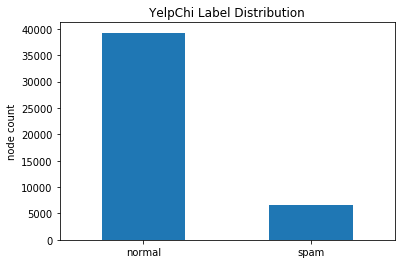

In [2]:
vc = pd.Series(label).map({0: "normal", 1: "spam"}).value_counts()
vc.plot(kind="bar")
plt.title("YelpChi Label Distribution")
plt.ylabel("node count")
plt.xticks(rotation=0)
plt.show()

## 3. 各关系的节点度分布

三种关系 `net_rsr / net_rtr / net_rur` 的稠密程度差异巨大，
按 99 分位裁剪后看节点度分布。

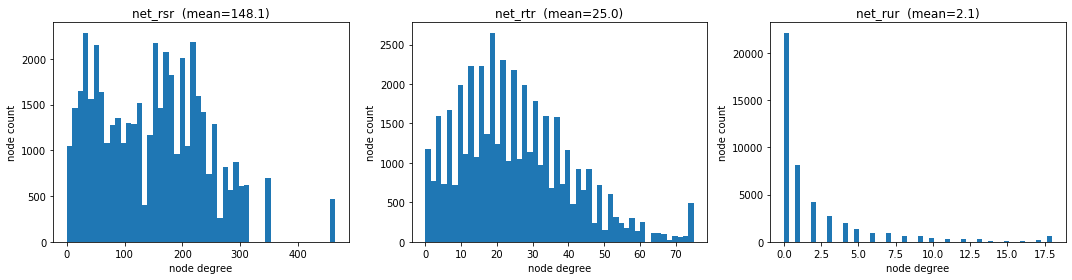

In [3]:
fig, axes = plt.subplots(1, len(relations), figsize=(15, 4))
for ax, rel in zip(axes, relations):
    d = deg[rel]
    cap = np.quantile(d, 0.99)
    ax.hist(np.clip(d, 0, cap), bins=50)
    ax.set_title(f"{rel}  (mean={d.mean():.1f})")
    ax.set_xlabel("node degree")
    ax.set_ylabel("node count")
plt.tight_layout()
plt.show()

## 4. 作弊率与节点度的关系

按节点总度数分十档，看每档的作弊率 —— 用于观察高连接度节点是否更易作弊
（与作弊伪装 camouflage 相关）。

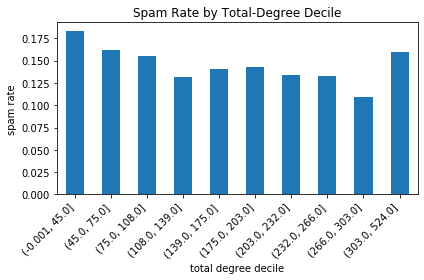

In [4]:
df = pd.DataFrame({"total_deg": total_deg, "label": label})
df["decile"] = pd.qcut(df["total_deg"], 10, duplicates="drop")
rate = df.groupby("decile")["label"].mean()
rate.plot(kind="bar")
plt.title("Spam Rate by Total-Degree Decile")
plt.ylabel("spam rate")
plt.xlabel("total degree decile")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 5. 节点特征概览

32 维特征已归一化到 [0, 1]。按标签对比每个节点的平均特征值分布。

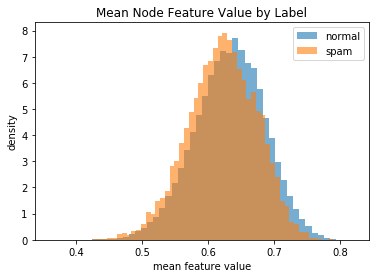

In [5]:
fmean = feature.mean(axis=1)
plt.hist(fmean[label == 0], bins=50, alpha=0.6, density=True, label="normal")
plt.hist(fmean[label == 1], bins=50, alpha=0.6, density=True, label="spam")
plt.title("Mean Node Feature Value by Label")
plt.xlabel("mean feature value")
plt.ylabel("density")
plt.legend()
plt.show()